In [2]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    average_precision_score,
    PrecisionRecallDisplay
)

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder, LabelEncoder
from collections import Counter

from sklearn.neural_network import MLPClassifier

# Pre-processing

We'll use fewer features than for the other models, in order to cut down on time for hyperparameter tuning.
- We'll only keep top 9 countries and regions
- delete hasAwards (corr to hasAwardsAndNominations)

In [3]:
data_dir = Path('../../results')

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [4]:
train = train.drop(columns=['hasAwards'])
test = test.drop(columns=['hasAwards'])

In [5]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

In [6]:
# Define target variables

y_train_rating = df_train['rating']
y_test_rating = df_test['rating']

y_train_titleType = df_train['titleType']
y_test_titleType = df_test['titleType']

In [7]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwardsOrNominations',
       'hasVideos', 'hasCriticsReviews', 'hasUserReviews',
       'moreDirectorsCredits', 'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [8]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


# Rating

## Pre-processing

In [9]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


In [10]:
# drop target variables
df_train.drop(columns=['rating', 'averageRating'], inplace=True) 
df_test.drop(columns=['rating', 'averageRating'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber', 'regions',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [11]:
num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
#cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions','rating']).index #drop the target var and lists
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [12]:
num_cols, bool_cols, cat_cols #NB: cat_cols only contains titleType, this is for rating as a target

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
        'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index(['titleType'], dtype='object'))

In [13]:
# Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

In [14]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [15]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 9
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

In [16]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

top_n_regions = 9
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [17]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        """Return feature names for output features"""
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [48]:
def build_preprocessor(num_cols, bool_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num_cols),
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),  # No need for drop='first': RF handles redundant feats
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

## Default

In [49]:
pipeline_rating = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42))
])

In [51]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
default_rating = cross_validate(
    pipeline_rating, 
    df_train, y_train_rating, 
    cv=sss, 
    scoring='f1_macro', 
    return_train_score=True, 
    n_jobs =-1)

print(f"Default parameters: {pipeline_rating.get_params()}")
print(f"Validation Macro F1: {default_rating['test_score'].mean():.3f}")
print(f"Train Macro F1: {default_rating['train_score'].mean():.3f}")


Default parameters: {'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num', RobustScaler(),
                                 Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
       'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
       'writerCredits', 'numGenres', 'criticReviewsRatio'],
      dtype='object')),
                                ('bool', 'passthrough',
                                 Index(['canHaveEpisodes', 'hasAwardsOrNominations', 'hasVideos',
       'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
       'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')),
                                ('cat', OneHotEncoder(),
                                 Index(['titleType'], dtype='object')),
                                ('countries', MultiLabelBinarizerTransformer(),
                                 'country_cleaned'),
                                ('genres', MultiLabelBinarizerTransfo

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


              precision    recall  f1-score   support

      (0, 1]      0.067     0.045     0.054        22
      (1, 2]      0.364     0.090     0.145       133
      (2, 3]      0.204     0.027     0.047       374
      (3, 4]      0.251     0.085     0.127      1035
      (4, 5]      0.362     0.158     0.220      2750
      (5, 6]      0.339     0.348     0.343      6270
      (6, 7]      0.391     0.421     0.405     11750
      (7, 8]      0.484     0.611     0.540     14613
      (8, 9]      0.348     0.277     0.309      6591
     (9, 10]      0.413     0.143     0.213      1319

    accuracy                          0.415     44857
   macro avg      0.322     0.221     0.240     44857
weighted avg      0.402     0.415     0.399     44857



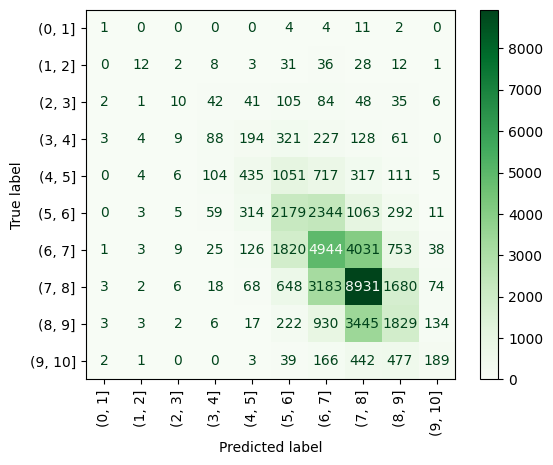

In [52]:
pipeline_rating.fit(df_train, y_train_rating)
y_pred_rating = pipeline_rating.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating, digits=3))
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_rating, y_true=y_test_rating,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()


It's slightly overfitted. Let's try it w/ early stopping.

In [53]:
pipeline_rating = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42, early_stopping=True))
])

In [55]:
# Encode the target variable → else error w/ early stopping
le = LabelEncoder()
y_train_rating_encoded = le.fit_transform(y_train_rating)

# Use encoded labels in cross_validate
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
default_rating = cross_validate(
    pipeline_rating, 
    df_train, y_train_rating_encoded,  # Use encoded version
    cv=sss, 
    scoring='f1_macro', 
    return_train_score=True, 
    n_jobs=-1)

print(f"Validation Macro F1: {default_rating['test_score'].mean():.3f}")
print(f"Train Macro F1: {default_rating['train_score'].mean():.3f}")

Validation Macro F1: 0.186
Train Macro F1: 0.195


As it happened w/ the other models, preventing overfitting leads to worse results.

## Hyperparameter tuning

In [56]:
pipeline_rating = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42))
])

In [61]:
param_list_one_hl = {
    'clf__hidden_layer_sizes': [(32,), (64,), (128,)],
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.0001, 0.001, 0.01]
}

param_list_two_hl = {
    'clf__hidden_layer_sizes': [(64,32), (128,64), (128,32)], # different decreasing pattern 
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.0001, 0.001, 0.01]
}

param_list_three_hl = {
    'clf__hidden_layer_sizes': [(128,64,32), (64,64,32)],
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.0001, 0.001, 0.01]
}

In [58]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

random_search_one_layer = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_one_hl,
    n_iter=25,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_one_layer.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_one_layer = random_search_one_layer.best_index_
train_macro_f1_one_layer = random_search_one_layer.cv_results_['mean_train_f1_macro'][best_index_one_layer]

print(f"Validation macro F1: {random_search_one_layer.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_one_layer:.3f}")
print(f"Best parameters: {random_search_one_layer.best_params_}")

Fitting 1 folds for each of 25 candidates, totalling 25 fits
BEST MODEL:
Validation macro F1: 0.253; vs macro F1 on train: 0.357
Best parameters: {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (128,), 'clf__alpha': 0.0001, 'clf__activation': 'relu'}


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [62]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

random_search_two_layers = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_two_hl,
    n_iter=25,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_two_layers.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_two_layers = random_search_two_layers.best_index_
train_macro_f1_two_layers = random_search_two_layers.cv_results_['mean_train_f1_macro'][best_index_two_layers]

print(f"Validation macro F1: {random_search_two_layers.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_two_layers:.3f}")
print(f"Best parameters: {random_search_two_layers.best_params_}")

Fitting 1 folds for each of 25 candidates, totalling 25 fits
BEST MODEL:
Validation macro F1: 0.262; vs macro F1 on train: 0.387
Best parameters: {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (128, 64), 'clf__alpha': 0.01, 'clf__activation': 'relu'}


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [63]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

random_search_three_layers = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_three_hl,
    n_iter=25,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_three_layers.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_three_layers = random_search_three_layers.best_index_
train_macro_f1_three_layers = random_search_three_layers.cv_results_['mean_train_f1_macro'][best_index_three_layers]

print(f"Validation macro F1: {random_search_three_layers.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_three_layers:.3f}")
print(f"Best parameters: {random_search_three_layers.best_params_}")

Fitting 1 folds for each of 25 candidates, totalling 25 fits
BEST MODEL:
Validation macro F1: 0.259; vs macro F1 on train: 0.428
Best parameters: {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__alpha': 0.01, 'clf__activation': 'relu'}


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [65]:
cv_results_one_hl = pd.DataFrame(random_search_one_layer.cv_results_)
cv_results_one_hl['overfitting_gap'] = cv_results_one_hl['mean_train_f1_macro'] - cv_results_one_hl['mean_test_f1_macro']

cv_results_two_hl = pd.DataFrame(random_search_two_layers.cv_results_)
cv_results_two_hl['overfitting_gap'] = cv_results_two_hl['mean_train_f1_macro'] - cv_results_two_hl['mean_test_f1_macro']

cv_results_three_hl = pd.DataFrame(random_search_three_layers.cv_results_)
cv_results_three_hl['overfitting_gap'] = cv_results_three_hl['mean_train_f1_macro'] - cv_results_three_hl['mean_test_f1_macro']

In [ ]:
"""
cv_results_one_hl.to_csv(data_dir/"cv_nn_one_hl_rating.csv", index=False)
cv_results_two_hl.to_csv(data_dir/"cv_nn_two_hl_rating.csv", index=False)
cv_results_three_hl.to_csv(data_dir/"cv_nn_three_hl_rating.csv", index=False)
"""

In [67]:
NN_rating = random_search_two_layers.best_estimator_
#joblib.dump(NN_rating, data_dir/"NN_rating.pkl")

['..\\..\\results\\NN_rating.pkl']

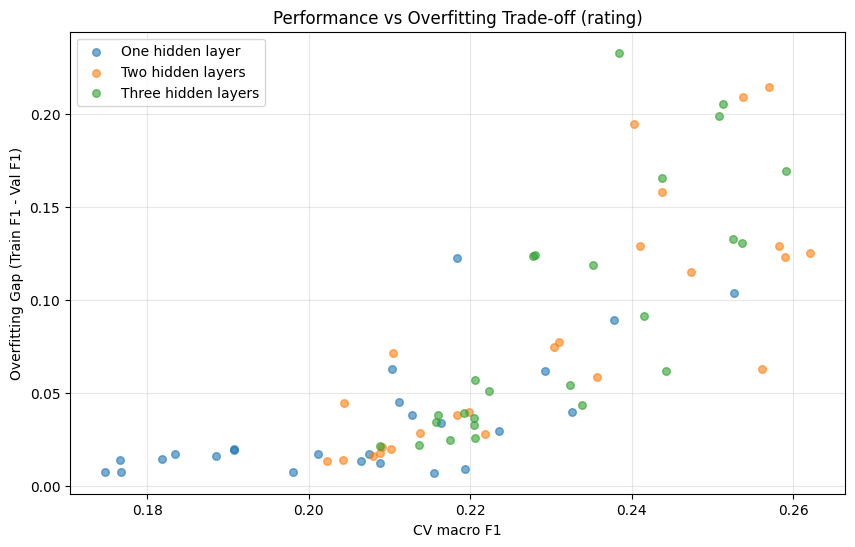

In [78]:
plt.figure(figsize=(10, 6))

plt.scatter(cv_results_one_hl["mean_test_f1_macro"], cv_results_one_hl["overfitting_gap"], 
           alpha=0.6, label="One hidden layer", s=30)
plt.scatter(cv_results_two_hl["mean_test_f1_macro"], cv_results_two_hl["overfitting_gap"], 
           alpha=0.6, label="Two hidden layers", s=30)
plt.scatter(cv_results_three_hl["mean_test_f1_macro"], cv_results_three_hl["overfitting_gap"], 
           alpha=0.6, label="Three hidden layers", s=30)

plt.xlabel("CV macro F1")
plt.ylabel("Overfitting Gap (Train F1 - Val F1)")
plt.title("Performance vs Overfitting Trade-off (rating)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Underfitted models: mostly one layer → let's look at cv_result to see if there are some particular params
- As performance increase, the overfitting gap tends to increase.

c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

              precision    recall  f1-score   support

      (0, 1]      0.000     0.000     0.000        22
      (1, 2]      0.237     0.105     0.146       133
      (2, 3]      0.185     0.045     0.073       374
      (3, 4]      0.256     0.107     0.151      1035
      (4, 5]      0.297     0.246     0.269      2750
      (5, 6]      0.345     0.302     0.322      6270
      (6, 7]      0.427     0.312     0.361     11750
      (7, 8]      0.465     0.681     0.552     14613
      (8, 9]      0.340     0.297     0.317      6591
     (9, 10]      0.335     0.197     0.248      1319

    accuracy                          0.413     44857
   macro avg      0.289     0.229     0.244     44857
weighted avg      0.398     0.413     0.394     44857



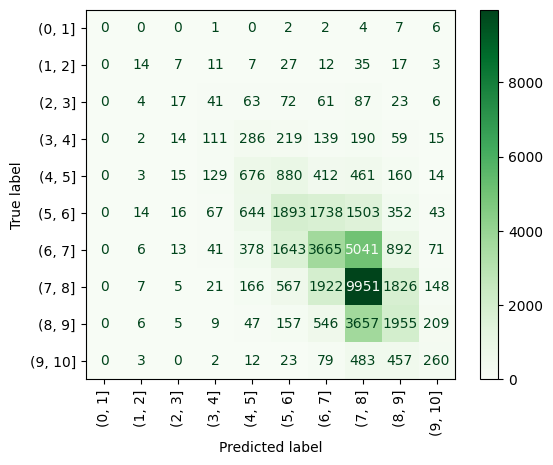

In [79]:
y_pred_rating = NN_rating.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating, digits=3))
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_rating, y_true=y_test_rating,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

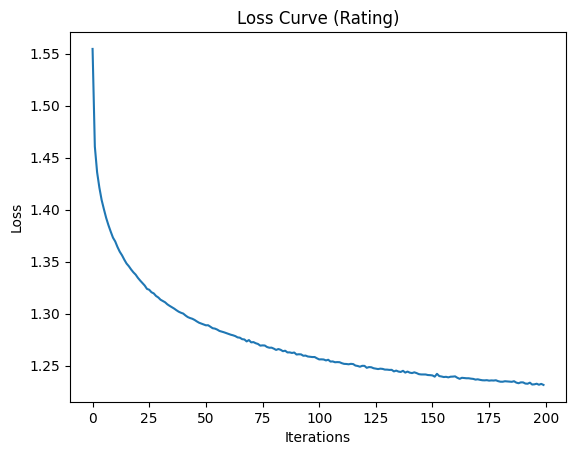

In [80]:
plt.plot(NN_rating.named_steps['clf'].loss_curve_)
plt.title("Loss Curve (Rating)") # training loss
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

slightly better than w/ default values.
Let's try the same architecture but with early stopping.

## Same params but w/ early stopping

In [81]:
pipeline_rating = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42, early_stopping=True))
])

In [84]:
best_params_rating = random_search_two_layers.best_params_
pipeline_rating.set_params(**best_params_rating)  # Set the best parameters

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
cv_results = cross_validate(
    pipeline_rating, 
    df_train, y_train_rating_encoded,  # Use encoded version
    cv=sss, 
    scoring='f1_macro', 
    return_train_score=True, 
    n_jobs=-1)

print(f"Validation Macro F1: {cv_results['test_score'].mean():.3f}")
print(f"Train Macro F1: {cv_results['train_score'].mean():.3f}")

Validation Macro F1: 0.210
Train Macro F1: 0.250


              precision    recall  f1-score   support

      (0, 1]      1.000     0.045     0.087        22
      (1, 2]      0.379     0.083     0.136       133
      (2, 3]      0.304     0.019     0.035       374
      (3, 4]      0.305     0.062     0.103      1035
      (4, 5]      0.351     0.199     0.254      2750
      (5, 6]      0.369     0.295     0.328      6270
      (6, 7]      0.419     0.361     0.388     11750
      (7, 8]      0.454     0.738     0.562     14613
      (8, 9]      0.368     0.216     0.272      6591
     (9, 10]      0.487     0.125     0.199      1319

    accuracy                          0.425     44857
   macro avg      0.444     0.214     0.236     44857
weighted avg      0.411     0.425     0.395     44857



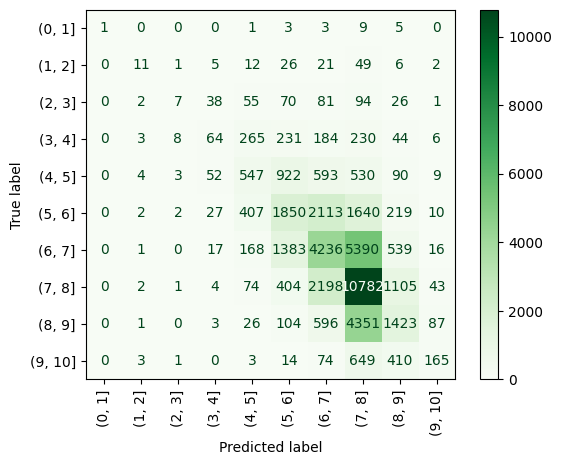

In [87]:
pipeline_rating.fit(df_train, y_train_rating_encoded)
y_pred_rating = pipeline_rating.predict(df_test)

# Decode the predictions back to original string labels
y_pred_rating = le.inverse_transform(y_pred_rating)

print(classification_report(y_test_rating, y_pred_rating, digits=3))
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_rating, y_true=y_test_rating,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

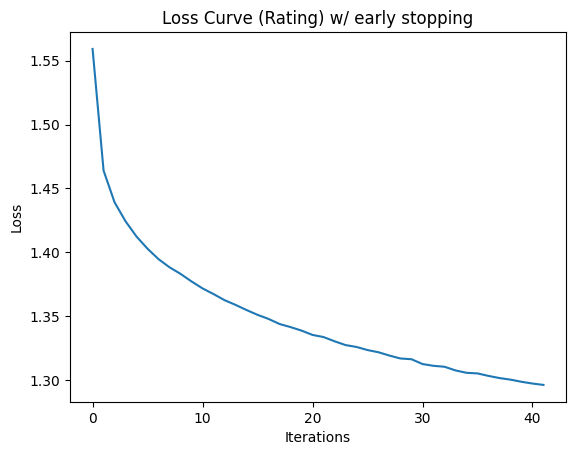

In [88]:
plt.plot(pipeline_rating.named_steps['clf'].loss_curve_)
plt.title("Loss Curve (Rating) w/ early stopping") # training loss
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

we stop at 40 iterations, performance on test set drops but by little (from 0.240 to 0.236) - accuracy actually increases (from 0.413 to 0.425)

# TitleType

## Pre-processing

In [20]:
# Overwrite
df_train = train.copy()
df_test = test.copy()

In [21]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwardsOrNominations',
       'hasVideos', 'hasCriticsReviews', 'hasUserReviews',
       'moreDirectorsCredits', 'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [22]:
# drop target variable and rating (we'll use averageRating)
df_train.drop(columns=['rating', 'titleType'], inplace=True) 
df_test.drop(columns=['rating', 'titleType'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'canHaveEpisodes', 'numRegions',
       'countryOfOrigin', 'genres', 'companiesNumber', 'averageRating',
       'regions', 'externalLinks', 'writerCredits', 'numGenres',
       'criticReviewsRatio', 'hasAwardsOrNominations', 'hasVideos',
       'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
       'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [23]:
# overwrite to make sure they're up to date

num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [24]:
num_cols, bool_cols, cat_cols

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'averageRating',
        'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index([], dtype='object'))

In [25]:
# Preprocess Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

## Default

In [100]:
pipeline_tts = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42))
])

In [102]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
default_tts = cross_validate(
    pipeline_tts, 
    df_train, y_train_titleType, 
    cv=sss, 
    scoring='f1_macro', 
    return_train_score=True, 
    n_jobs =-1)

#print(f"Default parameters: {pipeline_tts.get_params()}")
print(f"Validation Macro F1: {default_tts['test_score'].mean():.3f}")
print(f"Train Macro F1: {default_tts['train_score'].mean():.3f}")


Validation Macro F1: 0.726
Train Macro F1: 0.857


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


              precision    recall  f1-score   support

       movie      0.908     0.956     0.932     11045
       short      0.943     0.966     0.954      4930
   tvEpisode      0.987     0.990     0.988     21234
tvMiniSeries      0.613     0.580     0.596       491
     tvMovie      0.648     0.521     0.577      1861
    tvSeries      0.927     0.936     0.932      2820
     tvShort      0.444     0.136     0.209        88
   tvSpecial      0.616     0.544     0.578       327
       video      0.716     0.578     0.640      1535
   videoGame      0.903     0.880     0.891       526

    accuracy                          0.931     44857
   macro avg      0.770     0.709     0.730     44857
weighted avg      0.927     0.931     0.928     44857



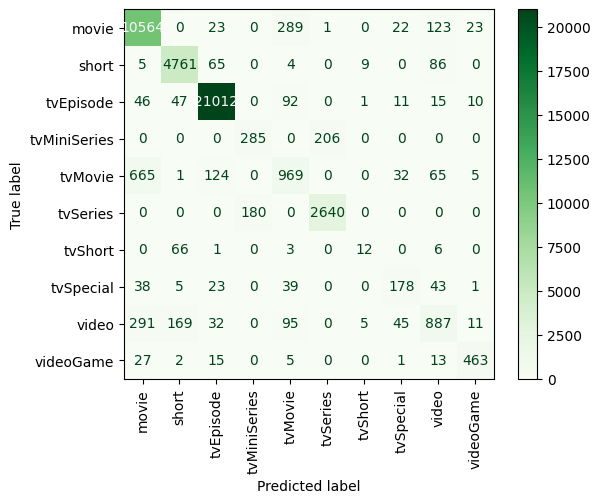

In [103]:
pipeline_tts.fit(df_train, y_train_titleType)
y_pred_tts = pipeline_tts.predict(df_test)
print(classification_report(y_test_titleType, y_pred_tts, digits=3))
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_tts, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()


It's slightly overfitted. Let's try it w/ early stopping.

In [104]:
pipeline_tts = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42, early_stopping=True))
])

In [106]:
# Encode the target variable → else error w/ early stopping
le = LabelEncoder()
y_train_titleType_encoded = le.fit_transform(y_train_titleType)

# Use encoded labels in cross_validate
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
default_titleType = cross_validate(
    pipeline_tts, 
    df_train, y_train_titleType_encoded,  # Use encoded version
    cv=sss, 
    scoring='f1_macro', 
    return_train_score=True, 
    n_jobs=-1)

print(f"Validation Macro F1: {default_titleType['test_score'].mean():.3f}")
print(f"Train Macro F1: {default_titleType['train_score'].mean():.3f}")

Validation Macro F1: 0.725
Train Macro F1: 0.794


              precision    recall  f1-score   support

       movie      0.904     0.962     0.932     11045
       short      0.939     0.977     0.958      4930
   tvEpisode      0.984     0.992     0.988     21234
tvMiniSeries      0.749     0.548     0.633       491
     tvMovie      0.674     0.498     0.573      1861
    tvSeries      0.925     0.968     0.946      2820
     tvShort      0.733     0.125     0.214        88
   tvSpecial      0.622     0.498     0.553       327
       video      0.773     0.532     0.630      1535
   videoGame      0.867     0.880     0.874       526

    accuracy                          0.934     44857
   macro avg      0.817     0.698     0.730     44857
weighted avg      0.928     0.934     0.929     44857



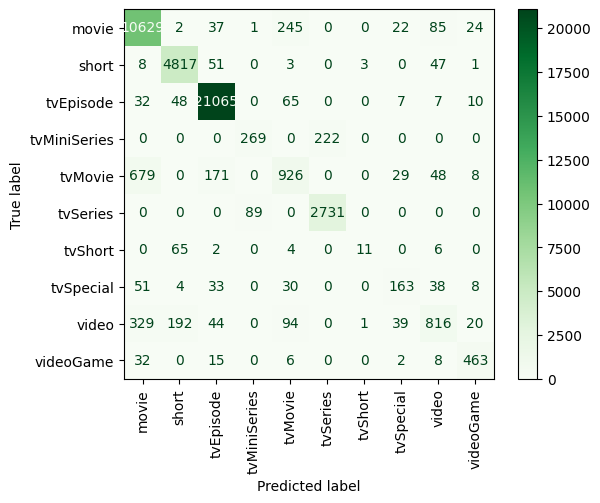

In [109]:
pipeline_tts.fit(df_train, y_train_titleType_encoded)
y_pred_tts = pipeline_tts.predict(df_test)

# Decode the predictions back to original string labels
y_pred_tts = le.inverse_transform(y_pred_tts)
print(classification_report(y_test_titleType, y_pred_tts, digits=3))
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_tts, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()


In this case, early stopping was a success: validation macro f1 was basically the same, on test we had an increase in accuracy. It's still mildly overfitted though.

## Hyperparameter tuning

In [110]:
pipeline_tts = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42))
])

In [111]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

random_search_1hl_tts = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_one_hl,
    n_iter=25,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_1hl_tts.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_one_layer = random_search_1hl_tts.best_index_
train_macro_f1_one_layer = random_search_1hl_tts.cv_results_['mean_train_f1_macro'][best_index_one_layer]

print(f"Validation macro F1: {random_search_1hl_tts.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_one_layer:.3f}")
print(f"Best parameters: {random_search_1hl_tts.best_params_}")

Fitting 1 folds for each of 25 candidates, totalling 25 fits
BEST MODEL:
Validation macro F1: 0.746; vs macro F1 on train: 0.791
Best parameters: {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (64,), 'clf__alpha': 0.01, 'clf__activation': 'tanh'}


In [112]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

random_search_2hl_tts = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_two_hl,
    n_iter=25,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_2hl_tts.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_two_layers = random_search_2hl_tts.best_index_
train_macro_f1_two_layers = random_search_2hl_tts.cv_results_['mean_train_f1_macro'][best_index_two_layers]

print(f"Validation macro F1: {random_search_2hl_tts.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_two_layers:.3f}")
print(f"Best parameters: {random_search_2hl_tts.best_params_}")

Fitting 1 folds for each of 25 candidates, totalling 25 fits
BEST MODEL:
Validation macro F1: 0.738; vs macro F1 on train: 0.777
Best parameters: {'clf__learning_rate_init': 0.0001, 'clf__hidden_layer_sizes': (128, 64), 'clf__alpha': 0.01, 'clf__activation': 'tanh'}


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [113]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

random_search_3hl_tts = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_three_hl,
    n_iter=25,
    cv=sss,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_3hl_tts.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_three_layers = random_search_3hl_tts.best_index_
train_macro_f1_three_layers = random_search_3hl_tts.cv_results_['mean_train_f1_macro'][best_index_three_layers]

print(f"Validation macro F1: {random_search_3hl_tts.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_three_layers:.3f}")
print(f"Best parameters: {random_search_3hl_tts.best_params_}")

Fitting 1 folds for each of 25 candidates, totalling 25 fits
BEST MODEL:
Validation macro F1: 0.740; vs macro F1 on train: 0.785
Best parameters: {'clf__learning_rate_init': 0.0001, 'clf__hidden_layer_sizes': (128, 64, 32), 'clf__alpha': 0.01, 'clf__activation': 'tanh'}


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [114]:
cv_results_one_hl_tts = pd.DataFrame(random_search_1hl_tts.cv_results_)
cv_results_one_hl_tts['overfitting_gap'] = cv_results_one_hl_tts['mean_train_f1_macro'] - cv_results_one_hl_tts['mean_test_f1_macro']

cv_results_two_hl_tts = pd.DataFrame(random_search_2hl_tts.cv_results_)
cv_results_two_hl_tts['overfitting_gap'] = cv_results_two_hl_tts['mean_train_f1_macro'] - cv_results_two_hl_tts['mean_test_f1_macro']

cv_results_three_hl_tts = pd.DataFrame(random_search_3hl_tts.cv_results_)
cv_results_three_hl_tts['overfitting_gap'] = cv_results_three_hl_tts['mean_train_f1_macro'] - cv_results_three_hl_tts['mean_test_f1_macro']

In [ ]:
"""
cv_results_one_hl_tts.to_csv(data_dir/"cv_nn_one_hl_tts.csv", index=False)
cv_results_two_hl_tts.to_csv(data_dir/"cv_nn_two_hl_tts.csv", index=False)
cv_results_three_hl_tts.to_csv(data_dir/"cv_nn_three_hl_tts.csv", index=False)
"""

In [119]:
NN_tts = random_search_1hl_tts.best_estimator_
#joblib.dump(NN_tts, data_dir/"NN_tts.pkl")

['..\\..\\results\\NN_tts.pkl']

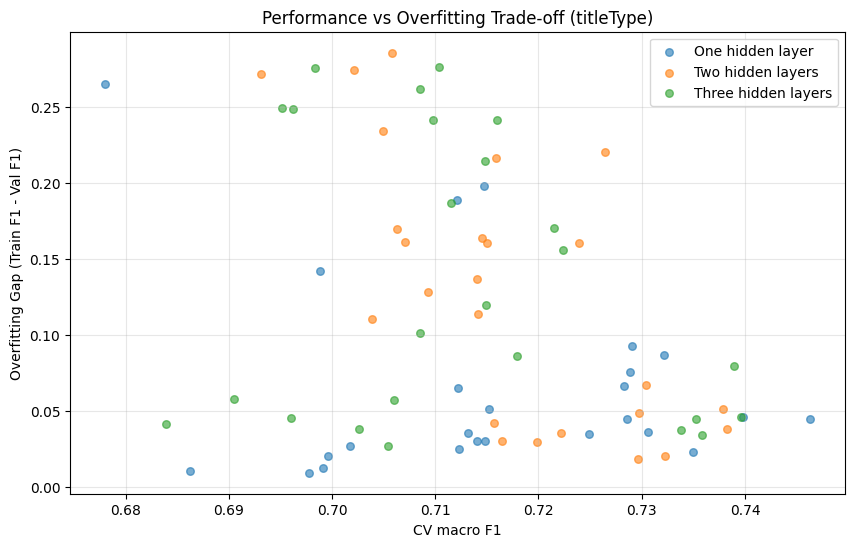

In [116]:
plt.figure(figsize=(10, 6))

plt.scatter(cv_results_one_hl_tts["mean_test_f1_macro"], cv_results_one_hl_tts["overfitting_gap"], 
           alpha=0.6, label="One hidden layer", s=30)
plt.scatter(cv_results_two_hl_tts["mean_test_f1_macro"], cv_results_two_hl_tts["overfitting_gap"], 
           alpha=0.6, label="Two hidden layers", s=30)
plt.scatter(cv_results_three_hl_tts["mean_test_f1_macro"], cv_results_three_hl_tts["overfitting_gap"], 
           alpha=0.6, label="Three hidden layers", s=30)

plt.xlabel("CV macro F1")
plt.ylabel("Overfitting Gap (Train F1 - Val F1)")
plt.title("Performance vs Overfitting Trade-off (titleType)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In this case, more layers do not necessarily mean better performance, but they do mean a tendency to overfit. Our best performing models are not severely overfit. The best overall performing model only has one layer w/ 64 neurons.

              precision    recall  f1-score   support

       movie      0.921     0.947     0.933     11045
       short      0.949     0.967     0.958      4930
   tvEpisode      0.983     0.993     0.988     21234
tvMiniSeries      0.717     0.613     0.661       491
     tvMovie      0.637     0.556     0.594      1861
    tvSeries      0.934     0.958     0.946      2820
     tvShort      0.476     0.114     0.183        88
   tvSpecial      0.623     0.535     0.576       327
       video      0.719     0.593     0.650      1535
   videoGame      0.893     0.884     0.888       526

    accuracy                          0.934     44857
   macro avg      0.785     0.716     0.738     44857
weighted avg      0.930     0.934     0.931     44857



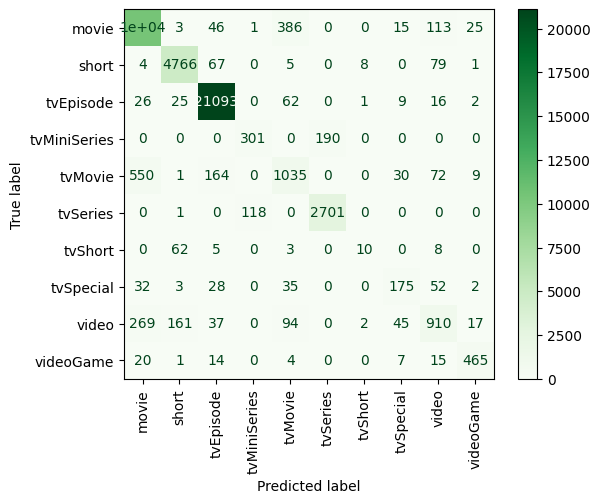

In [120]:
y_pred_titleType = NN_tts.predict(df_test)
print(classification_report(y_test_titleType, y_pred_titleType, digits=3))
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_titleType, y_true=y_test_titleType,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Decent results → got more than non linear svm on validation but less on test: non linear svm was severely overfitted, its memorization of minority classes helped boost its performance on test.

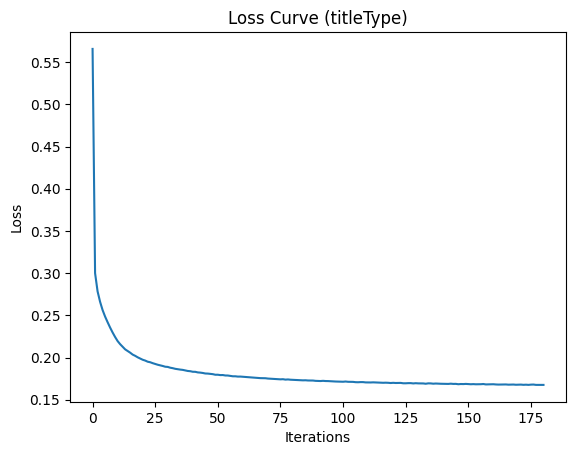

In [121]:
plt.plot(NN_tts.named_steps['clf'].loss_curve_)
plt.title("Loss Curve (titleType)") # training loss
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

Let's try it with early stopping.

## Same params but w/ early stopping

In [122]:
pipeline_tts = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', MLPClassifier(random_state=42, early_stopping=True))
])

In [123]:
best_params_tts = random_search_1hl_tts.best_params_
pipeline_tts.set_params(**best_params_tts)  # Set the best parameters

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
cv_results = cross_validate(
    pipeline_tts, 
    df_train, y_train_titleType_encoded,  # Use encoded version
    cv=sss, 
    scoring='f1_macro', 
    return_train_score=True, 
    n_jobs=-1)

print(f"Validation Macro F1: {cv_results['test_score'].mean():.3f}")
print(f"Train Macro F1: {cv_results['train_score'].mean():.3f}")

Validation Macro F1: 0.718
Train Macro F1: 0.750


              precision    recall  f1-score   support

       movie      0.920     0.947     0.934     11045
       short      0.941     0.972     0.956      4930
   tvEpisode      0.983     0.992     0.987     21234
tvMiniSeries      0.722     0.607     0.659       491
     tvMovie      0.646     0.557     0.598      1861
    tvSeries      0.934     0.959     0.946      2820
     tvShort      0.875     0.080     0.146        88
   tvSpecial      0.608     0.474     0.533       327
       video      0.720     0.591     0.649      1535
   videoGame      0.857     0.876     0.867       526

    accuracy                          0.934     44857
   macro avg      0.821     0.705     0.728     44857
weighted avg      0.930     0.934     0.930     44857



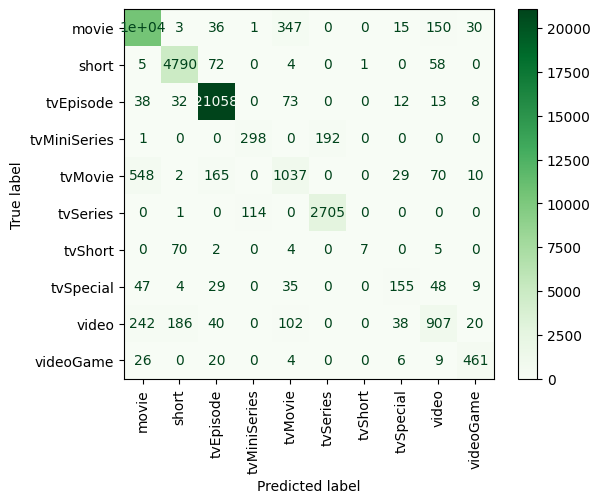

In [124]:
pipeline_tts.fit(df_train, y_train_titleType_encoded)
y_pred_tts = pipeline_tts.predict(df_test)

# Decode the predictions back to original string labels
y_pred_tts = le.inverse_transform(y_pred_tts)

print(classification_report(y_test_titleType, y_pred_tts, digits=3))
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_tts, y_true=y_test_titleType,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

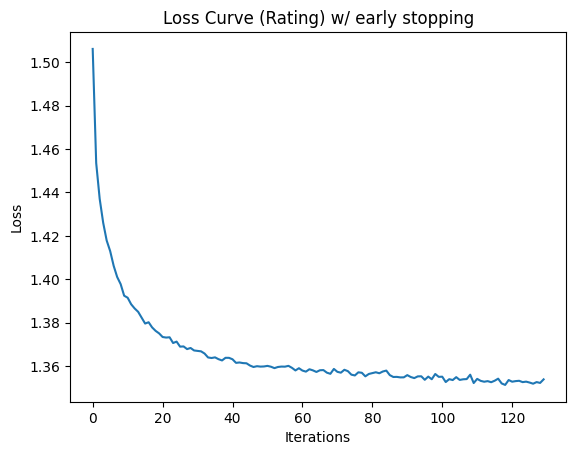

In [125]:
plt.plot(pipeline_rating.named_steps['clf'].loss_curve_)
plt.title("Loss Curve (Rating) w/ early stopping") # training loss
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

Minimally less overfitted, slightly lower performance.

# Addedum: PR Curves
Remember to prep df test according to the task

In [18]:
NN_rating = joblib.load(data_dir/"NN_rating.pkl")

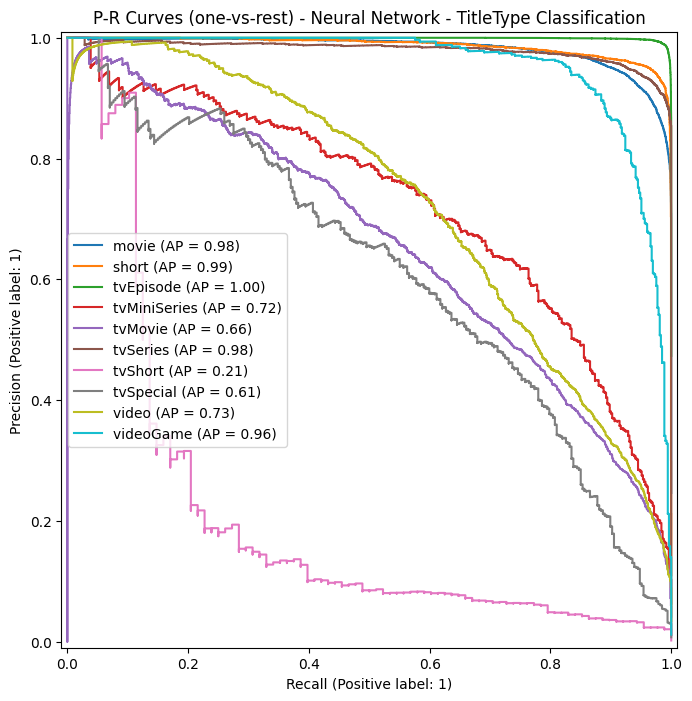

Macro average PR AUC: 0.784


In [27]:
# Get the classes and predictions from your pipeline
class_labels = NN_tts.classes_
y_score = NN_tts.predict_proba(df_test)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

# Plot PR curves
plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("P-R Curves (one-vs-rest) - Neural Network - TitleType Classification")
plt.show()

# Macro-average PR AUC
print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")